# Downstream Analysis

In [1]:
import os
import anndata as ad
import scanpy as sc
import scuva as scv
import numpy as np
import pandas as pd
import random
from matplotlib import pyplot as plt

In [2]:
from matplotlib import colors as mplc
_colors = ["lightgray", "royalblue", "gold"]
cmap = mplc.LinearSegmentedColormap.from_list("gray_blue_yellow", _colors)

SEED = 7
np.random.seed(SEED)
random.seed(SEED)

## Load Data

In [3]:
adata = ad.read_h5ad(os.path.join("data", "annotation_data.h5ad"))
adata

AnnData object with n_obs × n_vars = 44842 × 15611
    obs: 'full_hierarchical_labels', 'final_level_labels', 'final_level_confidence', 'full_consistent_hierarchy', 'azimuth_broad', 'azimuth_medium', 'azimuth_fine', 'scDblFinder.cluster', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.difficulty', 'scDblFinder.cxds_score', 'scDblFinder.mostLikelyOrigin', 'scDblFinder.originAmbiguous', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'is_outlier', 'leiden_resolution_0.3', 'leiden_resolution_0.4', 'leiden_resolution_0.5', 'leiden_resolution_0.6', 'cluster', 'celltypist_prediction', 'cell_type'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'h

In [4]:
samples = adata.obs["sample"].unique()
print(samples)
adata.obs["condition"] = adata.obs["sample"].map({
    "PBMC_Control1": "Control",
    "PBMC_Control2": "Control",
    "Lung_Cancer_PBMC": "Lung_Cancer"
}).astype("category")
condition = adata.obs["condition"].unique()
print(condition)
cell_types = adata.obs["cell_type"].unique()
print(cell_types)

['PBMC_Control1', 'PBMC_Control2', 'Lung_Cancer_PBMC']
Categories (3, object): ['PBMC_Control1', 'PBMC_Control2', 'Lung_Cancer_PBMC']
['Control', 'Lung_Cancer']
Categories (2, object): ['Control', 'Lung_Cancer']
['Naive/Tcm CD8 T', 'Activated CD4 T', 'Naive B', 'Naive/Tcm CD4 T', 'Th2', ..., 'Memory B', 'GZMK CD8 T', 'NK', 'CD16 Monocyte', 'DC']
Length: 12
Categories (12, object): ['Activated CD4 T', 'CD14 Monocyte', 'CD16 Monocyte', 'DC', ..., 'Naive B', 'Naive/Tcm CD4 T', 'Naive/Tcm CD8 T', 'Th2']


In [5]:
# uses scuva functionality for consistent naming
adata.uns["rename_dict"] = {
    "PBMC_Control1": "Control 1",
    "PBMC_Control2": "Control 2",
    "Lung_Cancer_PBMC": "Lung Cancer",
    "Control": "Control",
    "Lung_Cancer": "Lung_Cancer"
}

## General Figures and Cell Counts

### UMAP

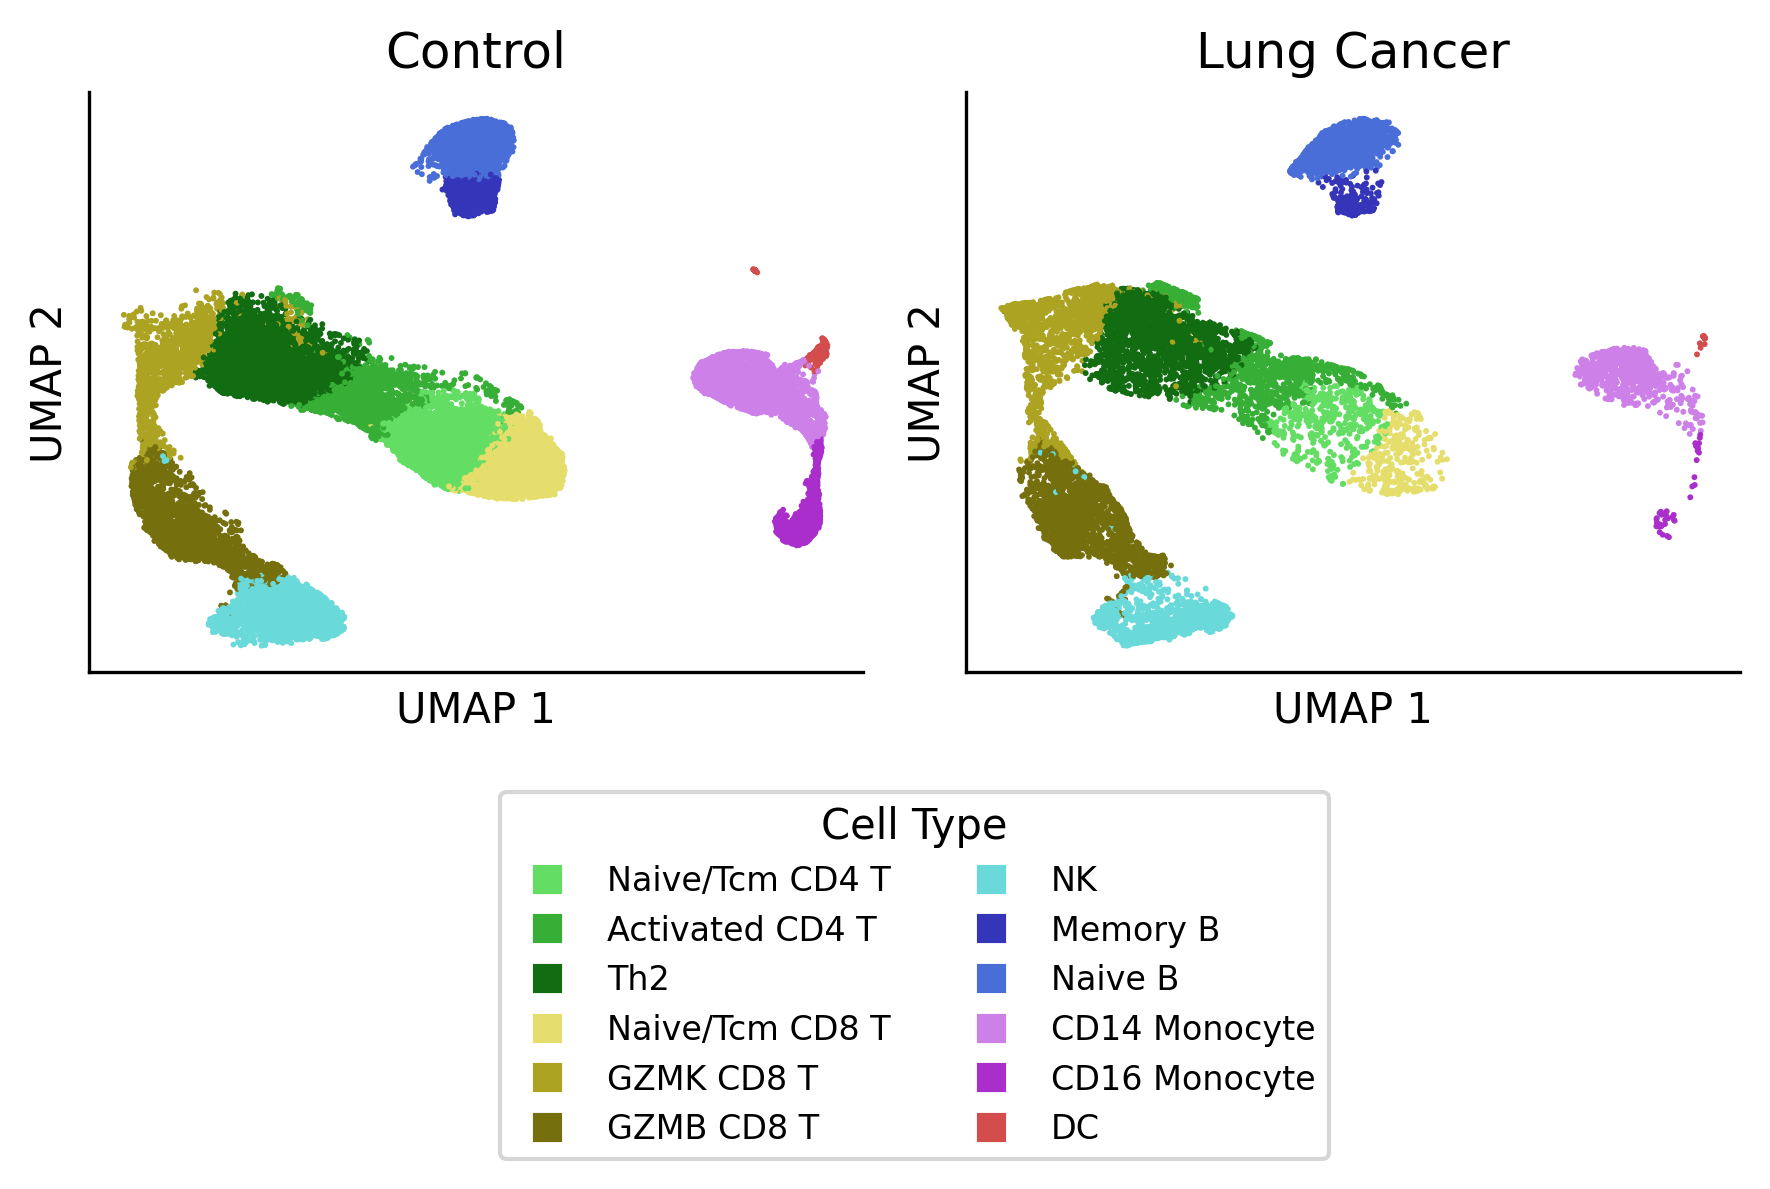

In [6]:
# umap_type_order = [
#     "AT1", "AT2 I", "AT2 II", "Club", "Goblet", "Ciliated", "Fibroblast", "Pericyte / VSMC",
#     "Alveolar Macrophage", "Interstitial Macrophage", "Monocyte-derived Macrophage", "IFN-Activated Macrophage", "cDC1", "cDC2", "Migratory cDC", "pDC",
#     "Treg", "Tfh", "Th17", "Naive CD8+ T", "Effector CD8+ T", "γδ T", "NK", "ILC2",
#     "IgA+ Plasma", "IgG1+ Plasma", "IgG2b+ Plasma", "IgG2c+ Plasma", "IgM+ Plasma", "aCap", "gCap", "Erythroid",
#     "Follicular B", "Activated B", "Circulating B", "Resident Memory B", "GC B", "Fcrl5+ Atypical B", "Neutrophil"
# ]
# for c in adata.obs["cell_type"].unique():
#     if c not in umap_type_order:
#         print(c)

order = [
    "Naive/Tcm CD4 T", "Activated CD4 T", "Th2",
    "Naive/Tcm CD8 T", "GZMK CD8 T", "GZMB CD8 T",
    "NK", "Memory B", "Naive B",
    "CD14 Monocyte", "CD16 Monocyte", "DC"
]

scv.umap_split(
    adata, 
    "cell_type", 
    "condition", 
    figsize=(6, 4),
    legend_kws=dict(ncol=2),
    legend_order=order,
    s=2,
)
plt.savefig(os.path.join("output", "figures", "cell_type_split.png"), bbox_inches="tight");

### Proportions

/Users/nirreiter/code/scuva/src/scuva/graphing/composition.py:174: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  bottom[i] + height/2,


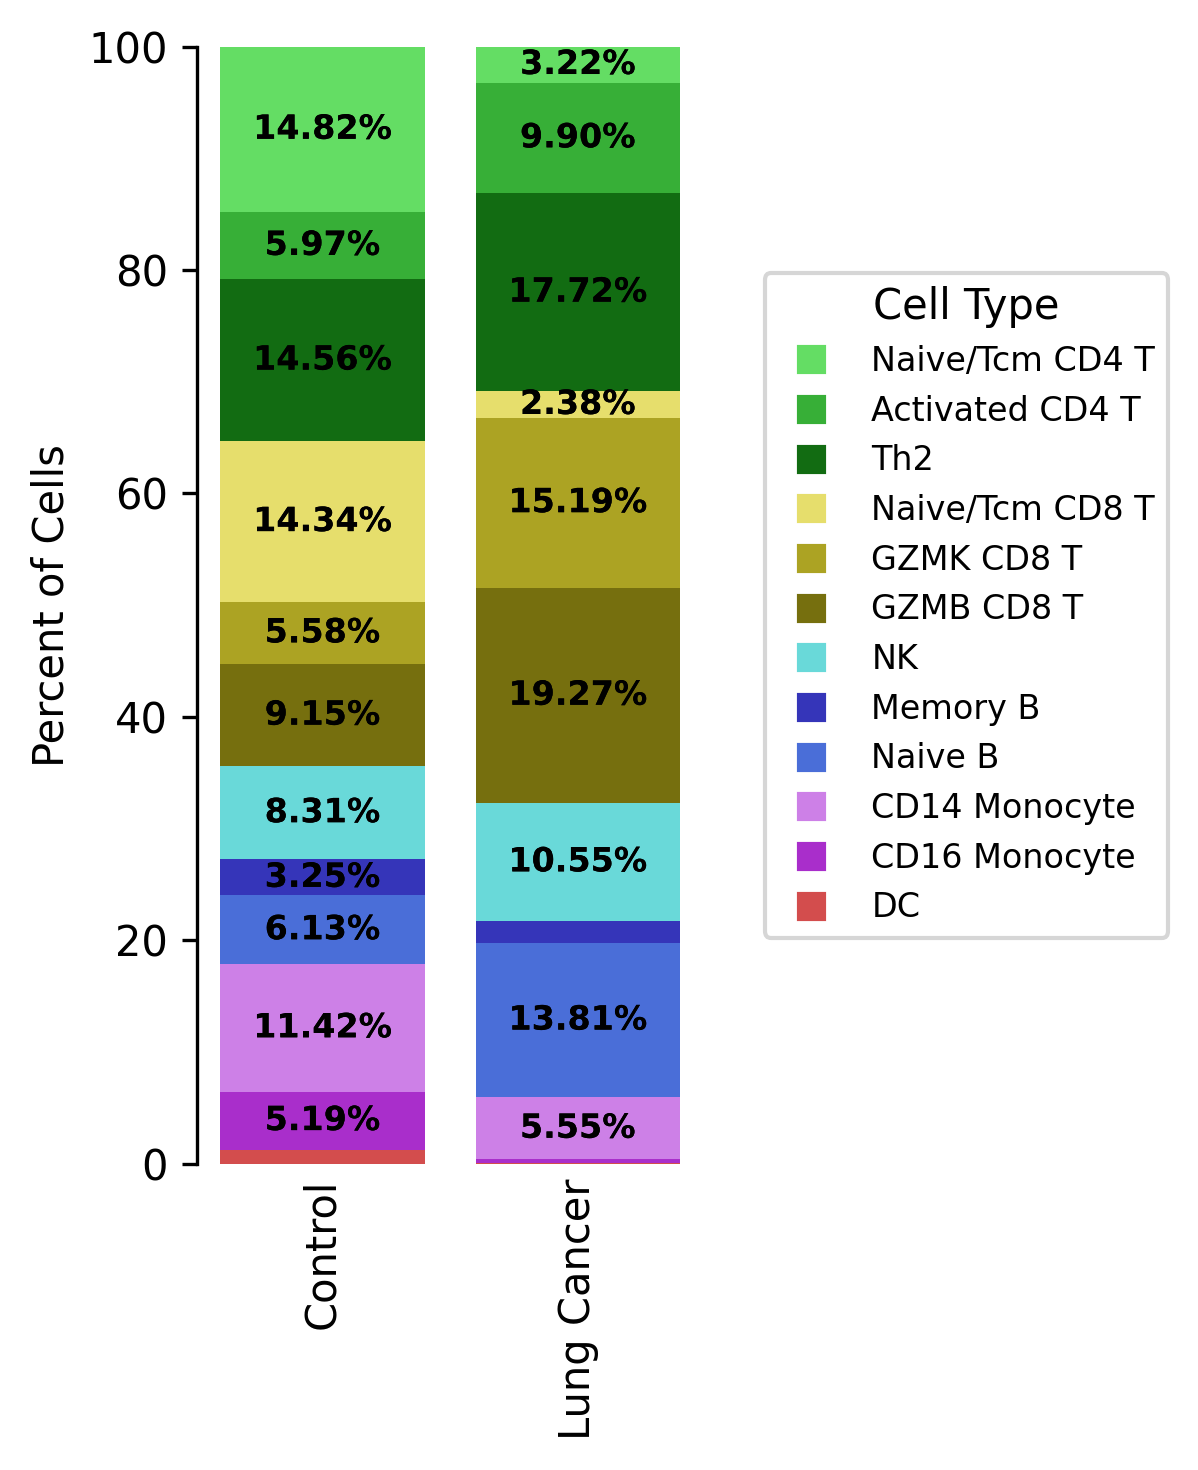

In [7]:
df, _, _, _ = scv.graph_proportions(
    adata, x="condition", y="cell_type",
    figsize=(4, 5), percentages_outline_width=0,
    percentages_display_threshold=2,
    x_tick_rotation=90, y_order=order
)

### Counts

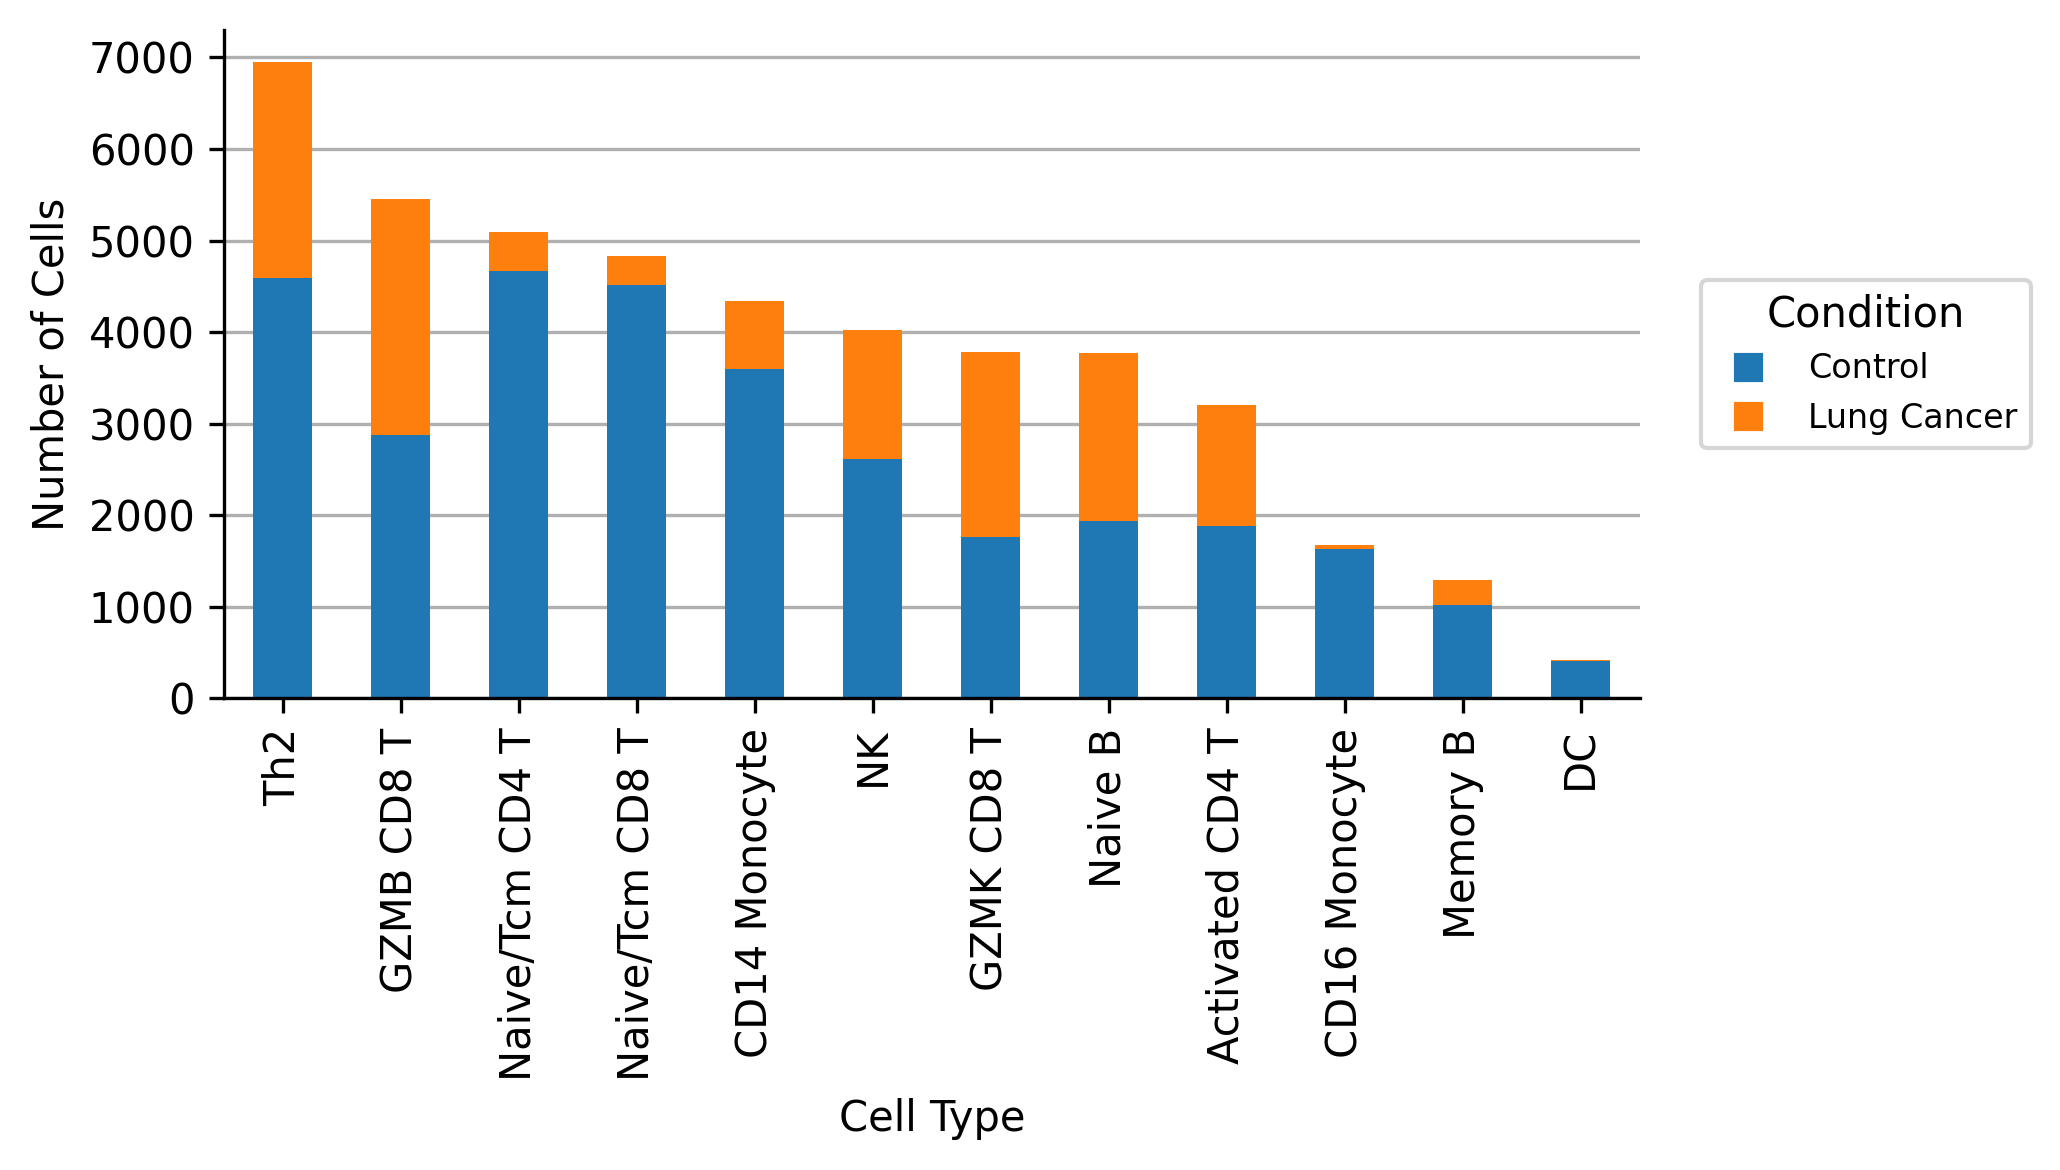

In [8]:
df, _, _, _ = scv.graph_counts(
    adata, hue="condition", x="cell_type",
    figsize=(7, 4), x_tick_rotation=90,
    stack=True
)